In [ ]:
image_path = '/home/emanmunir/detection/image (2).png'
image = Image.open(image_path).convert("RGB")
image

In [ ]:
image_path = '/home/emanmunir/detection/image (1).png'
image = Image.open(image_path).convert("RGB")
image

## **TROCR**

In [1]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

/home/emanmunir/detection/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-07-19 18:03:26.567493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-19 18:03:26.579867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-19 18:03:26.593041: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-19 18:03:26

In [8]:
image_path = '/home/emanmunir/detection/image (2).png'
image = Image.open(image_path).convert("RGB")

/home/emanmunir/detection/myenv/lib/python3.10/site-packages/transformers/generation/utils.py:1249: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


0 2


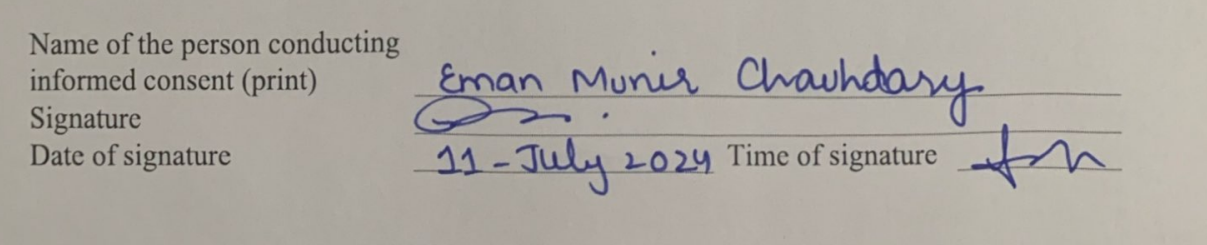

In [3]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_text)
image



## **EASYOCR**

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Text: Name of the person conducting, Probability: 0.7462334840455604
Text: informed consent (print), Probability: 0.8706536293206969
Text: Eman, Probability: 0.6143673658370972
Text: Muna, Probability: 0.5493502020835876
Text: Signature, Probability: 0.9990413672675427
Text: Date of signature, Probability: 0.6276895456431494
Text: 11, Probability: 0.9979371140549247
Text: 2024 Time of signature, Probability: 0.7365762669574921
Text: Chauhdovt, Probability: 0.28984329799082975
Text: Zjj, Probability: 0.23371799441178107


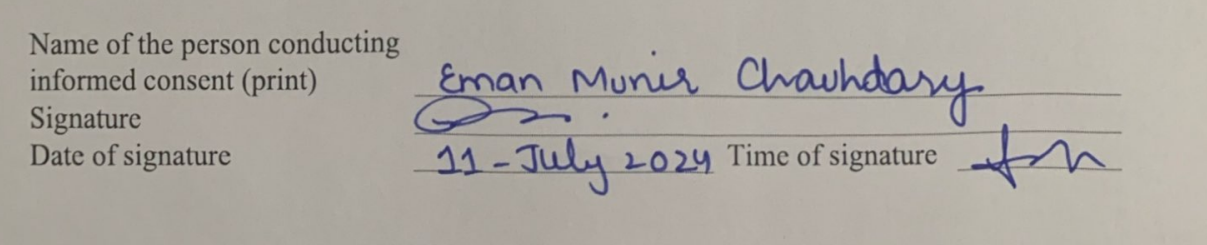

In [17]:
import easyocr

# Initialize the reader with the desired language(s)
reader = easyocr.Reader(['en'])


# Perform OCR on the image
results = reader.readtext(image_path)

# Print the results
for (bbox, text, prob) in results:
    print(f'Text: {text}, Probability: {prob}')

image


## **OCR DONUT**

In [22]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-to-text", model="jinhybr/OCR-Donut-CORD")

[{'generated_text': '<s_cord-v2><s_menu><s_nm> Name of the person conducting</s_nm><s_unitprice> @man Money</s_nm><s_price> Chauhdasy</s_nm><s_discount_price> 11 -July 2024</s_discount_price></s_sub_total><s_total><s_total_price> of signature</s_total_price><s_cashprice> 2024</s_cashprice></s_total>'}]


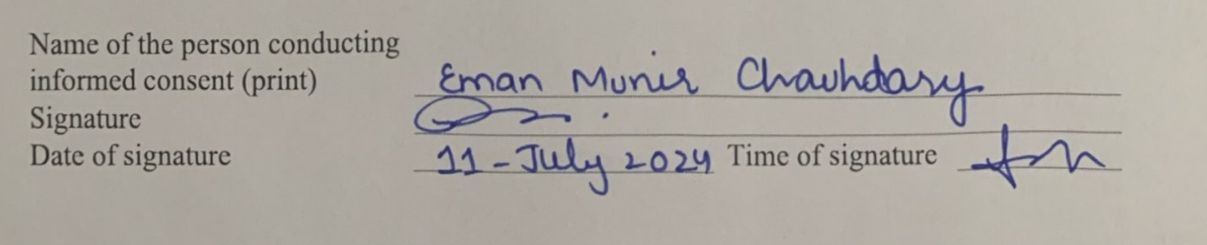

In [35]:
from PIL import Image

# Load your image  # Change this path to your image file path
image = Image.open(image_path)

# Use the pipeline to get text from the image
result = pipe(image)

# Print the result
print(result)
image

In [2]:
import pytesseract
from PIL import Image




text = pytesseract.image_to_string(image)

print(text)
image


Name of the person conducting

informed consent (print) Ernan Mor, Clrowhdo4.
tt

Signature

 

Date of signature AA -dul 4 X02 Time of signature AN

